### Soil Prediction Using Machine Learning

In [1]:

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, multilabel_confusion_matrix
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve


import warnings
warnings.filterwarnings('ignore')



#### 1. Data Cleaning and Processing

In [2]:
df = pd.read_csv('Final_Final_Soil.csv')
df

,Soil_Moisture,Temperature,Soil_Texture,Humidity,Rainfall,Sunlight,pH,EC,Organic_Matter,Nitrogen,...,Potassium,Zinc,Iron,Manganese,Soil_Quality_Index,Crop_Prediction,Yield,Soil_Quality,Total_Weight_KG/H,Market_Rate
0,29.7,35.2,4,58.0,10.0,6.5,6.5,1.1,8.6,31.0,...,105.8,4.6,93.1,21.0,9.8,Maize,72033.333333,Excellent,10805,0.15
1,31.8,29.4,4,58.8,6.0,8.7,5.0,2.9,0.5,22.3,...,156.3,3.2,57.2,26.4,9.0,Potato,19620.000000,Excellent,4905,0.25
2,29.6,21.5,2,35.8,228.9,6.1,6.3,0.8,0.9,30.4,...,170.6,8.5,26.7,46.8,5.0,Flax,1942.857143,Fair,1360,0.70
3,29.6,12.0,2,33.3,281.1,9.0,6.8,1.5,8.5,37.7,...,151.4,2.9,30.6,17.4,6.7,Sorghum,25555.555556,Fair,4600,0.18
4,11.4,20.1,2,37.8,207.0,5.0,7.4,1.0,9.5,27.6,...,149.8,6.7,33.8,44.1,5.7,Groundnut,2777.777778,Fair,2500,0.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1420,22.1,23.1,1,26.9,274.2,4.1,5.8,2.5,8.4,34.1,...,140.5,6.3,16.0,38.5,3.1,Mustard,3148.333333,Poor,1889,0.60
1421,11.1,24.3,0,50.8,44.2,10.9,6.9,0.1,3.5,32.7,...,191.8,3.1,81.0,40.6,1.6,Pearl Millet,5213.333333,Very Poor,1564,0.30
1422,25.7,17.3,1,32.3,127.0,7.8,6.7,1.0,3.0,42.5,...,118.7,8.3,37.8,29.0,3.3,Mustard,3148.333333,Poor,1889,0.60
1423,27.2,34.5,0,40.0,141.1,11.0,5.0,2.4,3.0,20.1,...,138.8,9.8,25.4,35.1,2.2,Quinoa,392.857143,Very Poor,1375,3.50


In [3]:
df.shape

(1425, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1425 entries, 0 to 1424
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Soil_Moisture       1425 non-null   float64
 1   Temperature         1425 non-null   float64
 2   Soil_Texture        1425 non-null   int64  
 3   Humidity            1425 non-null   float64
 4   Rainfall            1425 non-null   float64
 5   Sunlight            1425 non-null   float64
 6   pH                  1425 non-null   float64
 7   EC                  1425 non-null   float64
 8   Organic_Matter      1425 non-null   float64
 9   Nitrogen            1425 non-null   float64
 10  Phosphorus          1425 non-null   float64
 11  Potassium           1425 non-null   float64
 12  Zinc                1425 non-null   float64
 13  Iron                1425 non-null   float64
 14  Manganese           1425 non-null   float64
 15  Soil_Quality_Index  1425 non-null   float64
 16  Crop_P

In [5]:
df.head()

,Soil_Moisture,Temperature,Soil_Texture,Humidity,Rainfall,Sunlight,pH,EC,Organic_Matter,Nitrogen,...,Potassium,Zinc,Iron,Manganese,Soil_Quality_Index,Crop_Prediction,Yield,Soil_Quality,Total_Weight_KG/H,Market_Rate
0,29.7,35.2,4,58.0,10.0,6.5,6.5,1.1,8.6,31.0,...,105.8,4.6,93.1,21.0,9.8,Maize,72033.333333,Excellent,10805,0.15
1,31.8,29.4,4,58.8,6.0,8.7,5.0,2.9,0.5,22.3,...,156.3,3.2,57.2,26.4,9.0,Potato,19620.000000,Excellent,4905,0.25
2,29.6,21.5,2,35.8,228.9,6.1,6.3,0.8,0.9,30.4,...,170.6,8.5,26.7,46.8,5.0,Flax,1942.857143,Fair,1360,0.70
3,29.6,12.0,2,33.3,281.1,9.0,6.8,1.5,8.5,37.7,...,151.4,2.9,30.6,17.4,6.7,Sorghum,25555.555556,Fair,4600,0.18
4,11.4,20.1,2,37.8,207.0,5.0,7.4,1.0,9.5,27.6,...,149.8,6.7,33.8,44.1,5.7,Groundnut,2777.777778,Fair,2500,0.90


In [6]:
df.isna().sum()

Soil_Moisture         0
Temperature           0
Soil_Texture          0
Humidity              0
Rainfall              0
Sunlight              0
pH                    0
EC                    0
Organic_Matter        0
Nitrogen              0
Phosphorus            0
Potassium             0
Zinc                  0
Iron                  0
Manganese             0
Soil_Quality_Index    0
Crop_Prediction       0
Yield                 0
Soil_Quality          0
Total_Weight_KG/H     0
Market_Rate           0
dtype: int64

In [7]:
df.dtypes

Soil_Moisture         float64
Temperature           float64
Soil_Texture            int64
Humidity              float64
Rainfall              float64
Sunlight              float64
pH                    float64
EC                    float64
Organic_Matter        float64
Nitrogen              float64
Phosphorus            float64
Potassium             float64
Zinc                  float64
Iron                  float64
Manganese             float64
Soil_Quality_Index    float64
Crop_Prediction        object
Yield                 float64
Soil_Quality           object
Total_Weight_KG/H       int64
Market_Rate           float64
dtype: object

#### 2. Data Exploration (EDA Exploratory Data Analysis)

In [8]:
df.describe()

,Soil_Moisture,Temperature,Soil_Texture,Humidity,Rainfall,Sunlight,pH,EC,Organic_Matter,Nitrogen,Phosphorus,Potassium,Zinc,Iron,Manganese,Soil_Quality_Index,Yield,Total_Weight_KG/H,Market_Rate
count,1425.000000,1425.000000,1425.000000,1425.000000,1425.000000,1425.000000,1425.000000,1425.000000,1425.000000,1425.000000,1425.000000,1425.000000,1425.000000,1425.000000,1425.000000,1425.000000,1.425000e+03,1425.000000,1425.000000
mean,19.808561,24.914877,1.903158,54.185544,149.172211,8.034596,6.720561,1.478737,5.076912,35.346456,37.736561,149.396421,5.479298,55.741193,27.693474,5.605965,1.020077e+05,6349.394386,0.926302
std,8.530597,8.587215,1.414868,20.057418,84.090193,2.289618,1.293623,0.870912,2.841525,8.583563,7.298934,28.513178,2.574791,26.093869,12.853402,2.642455,4.186575e+05,16390.689172,1.090910
min,5.000000,10.000000,0.000000,20.000000,0.100000,4.000000,4.500000,0.000000,0.000000,20.000000,25.000000,100.200000,1.000000,10.000000,5.000000,1.000000,3.928571e+02,948.000000,0.040000
25%,12.300000,17.500000,1.000000,37.400000,79.900000,6.000000,5.600000,0.700000,2.600000,28.400000,31.500000,124.400000,3.300000,33.500000,16.600000,3.200000,1.543750e+03,1338.000000,0.250000
50%,19.800000,24.700000,2.000000,53.800000,149.500000,8.100000,6.700000,1.500000,5.300000,35.000000,37.700000,149.100000,5.400000,55.100000,28.000000,5.700000,4.460000e+03,1889.000000,0.400000
75%,27.300000,32.500000,3.000000,71.700000,220.000000,10.000000,7.800000,2.200000,7.500000,42.700000,44.100000,173.400000,7.700000,78.700000,38.700000,8.000000,1.760000e+04,3520.000000,0.900000
max,35.000000,40.000000,4.000000,90.000000,299.400000,12.000000,9.000000,3.000000,10.000000,50.000000,50.000000,199.600000,10.000000,100.000000,50.000000,10.000000,2.000000e+06,80000.000000,3.500000


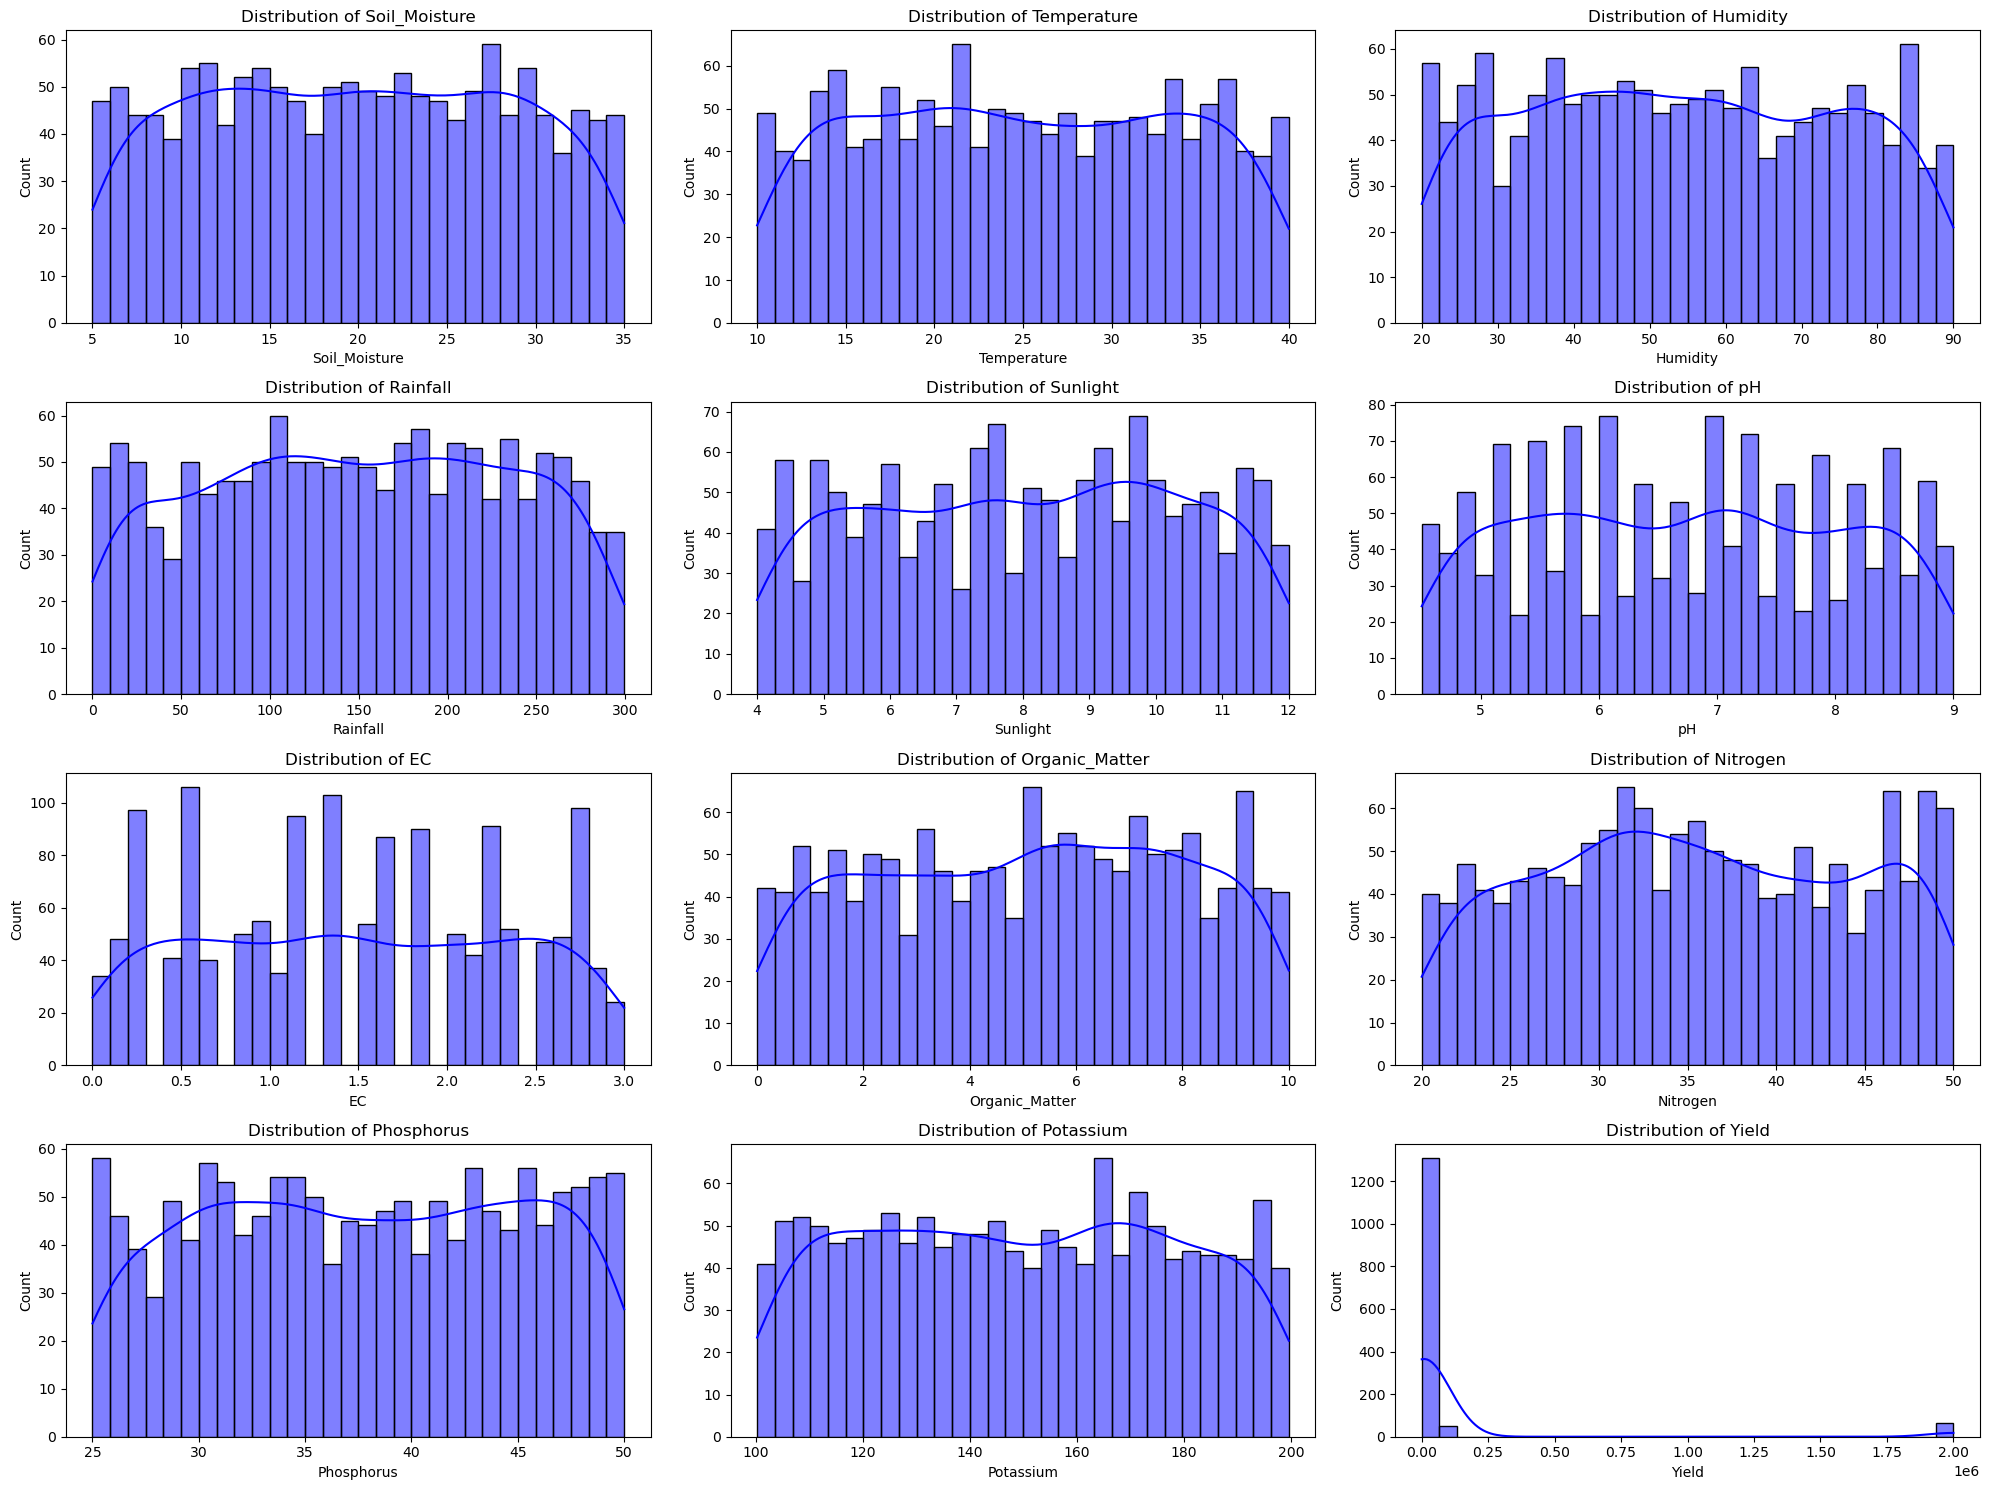

In [9]:
# Plot distributions of key numerical features
numerical_columns = [
    "Soil_Moisture", "Temperature", "Humidity", "Rainfall", "Sunlight", 
    "pH", "EC", "Organic_Matter", "Nitrogen", "Phosphorus", "Potassium", "Yield"
]

plt.figure(figsize=(20, 15))
for i, column in enumerate(numerical_columns, 1):
    plt.subplot(4, 3, i)
    sns.histplot(df[column], kde=True, bins=30, color="blue")
    plt.title(f"Distribution of {column}")

plt.tight_layout()
plt.show()


<Axes: ylabel='Total_Weight_KG/H'>

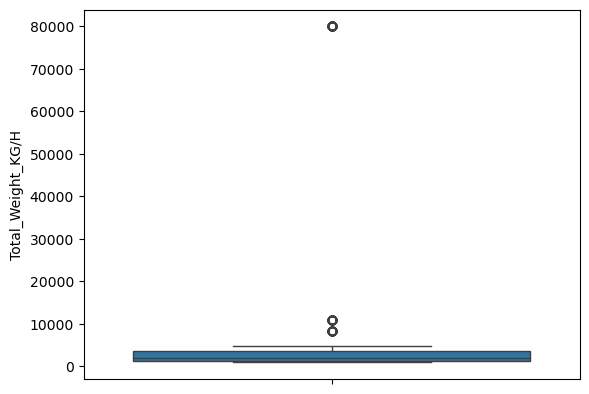

In [10]:
sns.boxplot(df['Total_Weight_KG/H'])

In [11]:
q1 = df['Total_Weight_KG/H'].quantile(0.25)
q3 = df['Total_Weight_KG/H'].quantile(0.75)
iqr = q3 - q1
upper_limit = q3 + 1.5*iqr
upper_limit

6793.0

<Axes: ylabel='Market_Rate'>

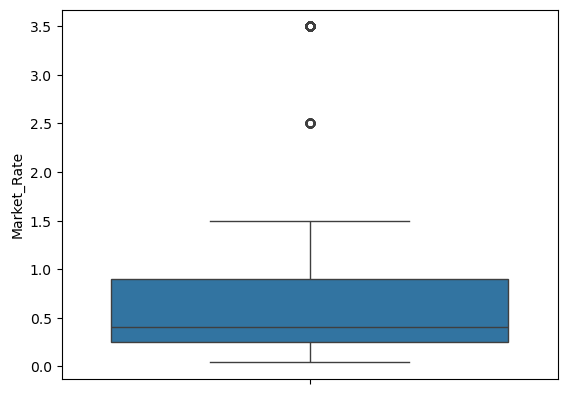

In [12]:
sns.boxplot(df['Market_Rate'])

In [13]:
q1 = df['Market_Rate'].quantile(0.25)
q3 = df['Market_Rate'].quantile(0.75)
iqr = q3 - q1
upper_limit = q3 + 1.5*iqr
upper_limit

1.875

In [14]:
# Assuming 'df' is your DataFrame and 'Total_Weight_KG/H' is the column

# Calculate the IQR
q1 = df['Market_Rate'].quantile(0.25)
q3 = df['Market_Rate'].quantile(0.75)
iqr = q3 - q1

# Calculate the upper and lower bounds
lower_limit = q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr

# Filter out the outliers
df_filtered = df[(df['Market_Rate'] >= lower_limit) & (df['Market_Rate'] <= upper_limit)]


<Axes: ylabel='Soil_Quality_Index'>

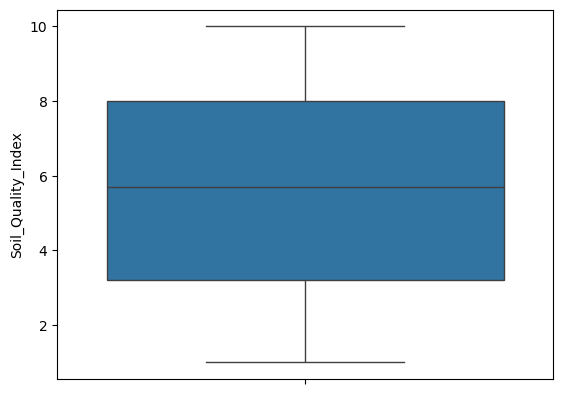

In [15]:
sns.boxplot(df['Soil_Quality_Index'])

<Axes: ylabel='Manganese'>

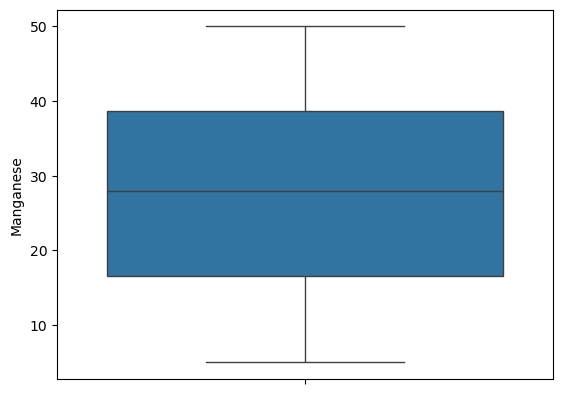

In [16]:
sns.boxplot(df['Manganese'])

<Axes: ylabel='Iron'>

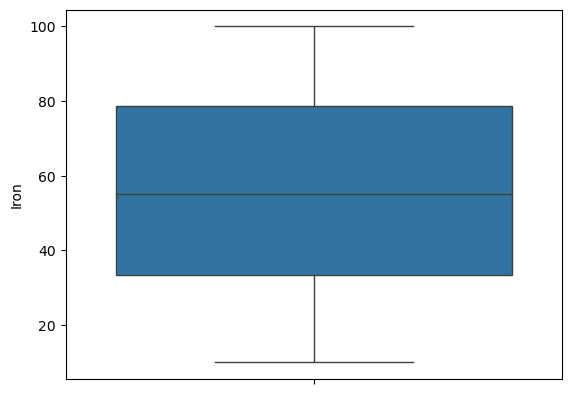

In [17]:
sns.boxplot(df['Iron'])

<Axes: ylabel='Zinc'>

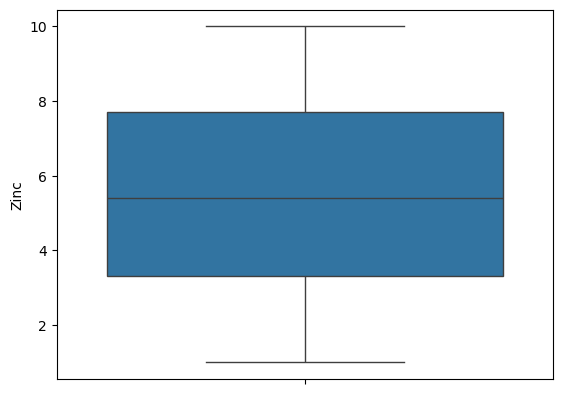

In [25]:
sns.boxplot(df['Zinc'])

<Axes: ylabel='Potassium'>

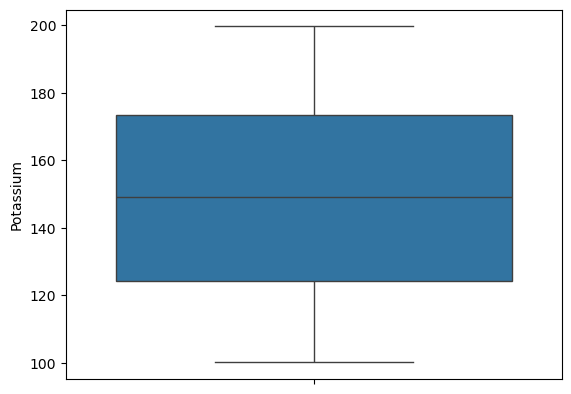

In [18]:
sns.boxplot(df['Potassium'])

<Axes: ylabel='Nitrogen'>

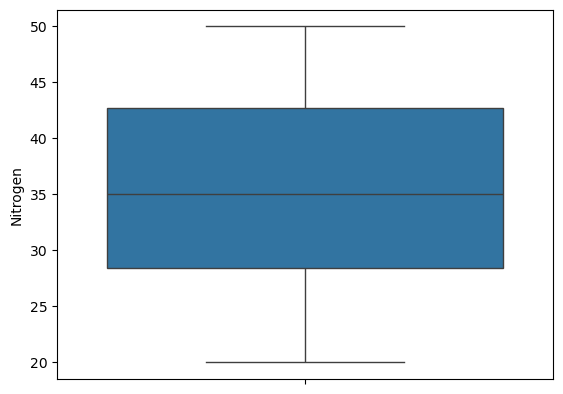

In [19]:
sns.boxplot(df['Nitrogen'])

<Axes: ylabel='Organic_Matter'>

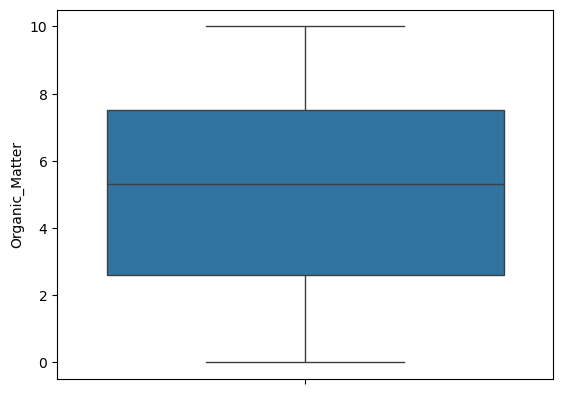

In [20]:
sns.boxplot(df['Organic_Matter'])

<Axes: ylabel='EC'>

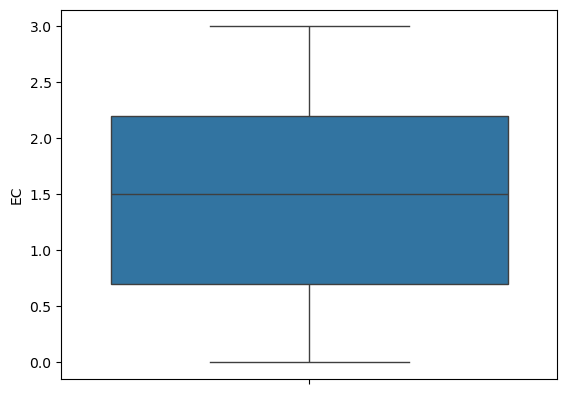

In [21]:
sns.boxplot(df['EC'])

<Axes: ylabel='pH'>

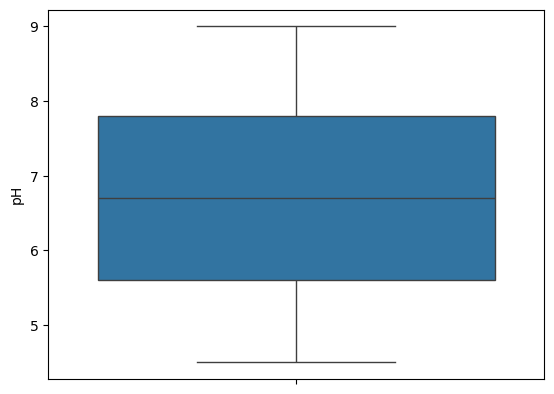

In [22]:
sns.boxplot(df['pH'])

<Axes: ylabel='Sunlight'>

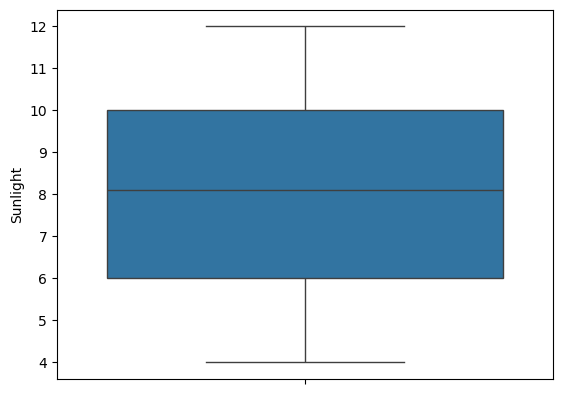

In [23]:
sns.boxplot(df['Sunlight'])

<Axes: ylabel='Rainfall'>

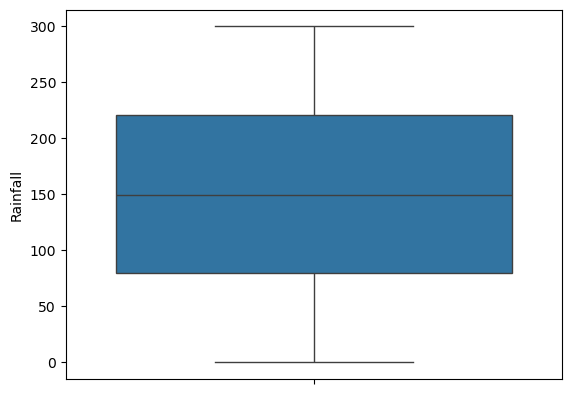

In [24]:
sns.boxplot(df['Rainfall'])

<Axes: ylabel='Humidity'>

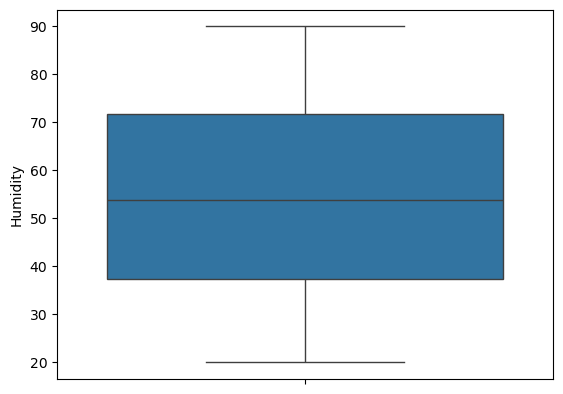

In [25]:
sns.boxplot(df['Humidity'])

<Axes: ylabel='Soil_Texture'>

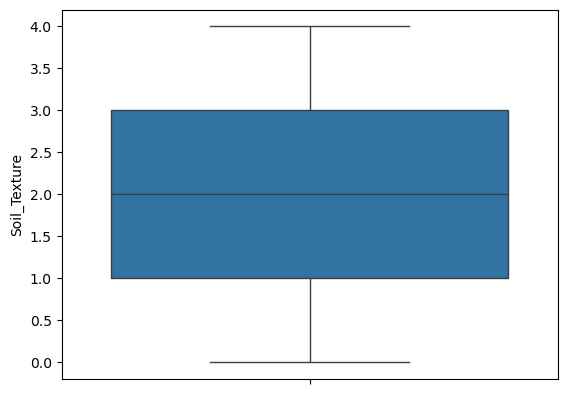

In [26]:
sns.boxplot(df['Soil_Texture'])

<Axes: ylabel='Temperature'>

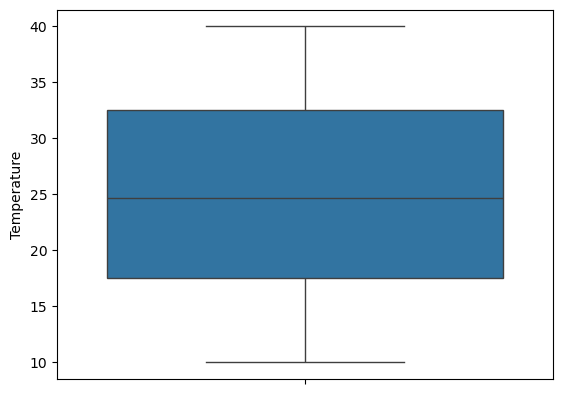

In [35]:
sns.boxplot(df['Temperature'])

<Axes: ylabel='Soil_Moisture'>

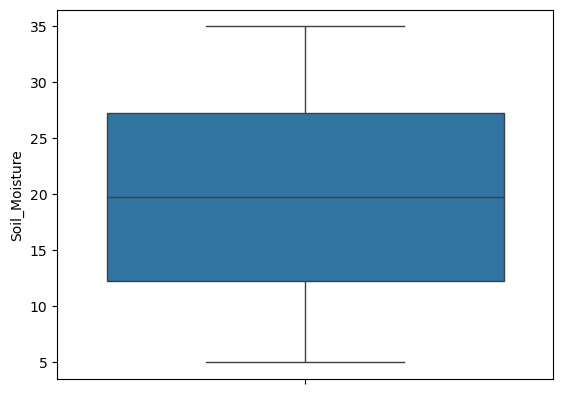

In [27]:
sns.boxplot(df['Soil_Moisture'])

#### 3. Feature engineering and feature selection

In [28]:
# Initialize the LabelEncoder
label_encoder = LabelEncoder()
df['Soil_Texture'] = label_encoder.fit_transform(df['Soil_Texture'])
soil_texture_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
#print("Soil_Texture encoding:", soil_texture_mapping)

In [29]:
df

,Soil_Moisture,Temperature,Soil_Texture,Humidity,Rainfall,Sunlight,pH,EC,Organic_Matter,Nitrogen,...,Potassium,Zinc,Iron,Manganese,Soil_Quality_Index,Crop_Prediction,Yield,Soil_Quality,Total_Weight_KG/H,Market_Rate
0,29.7,35.2,4,58.0,10.0,6.5,6.5,1.1,8.6,31.0,...,105.8,4.6,93.1,21.0,9.8,Maize,72033.333333,Excellent,10805,0.15
1,31.8,29.4,4,58.8,6.0,8.7,5.0,2.9,0.5,22.3,...,156.3,3.2,57.2,26.4,9.0,Potato,19620.000000,Excellent,4905,0.25
2,29.6,21.5,2,35.8,228.9,6.1,6.3,0.8,0.9,30.4,...,170.6,8.5,26.7,46.8,5.0,Flax,1942.857143,Fair,1360,0.70
3,29.6,12.0,2,33.3,281.1,9.0,6.8,1.5,8.5,37.7,...,151.4,2.9,30.6,17.4,6.7,Sorghum,25555.555556,Fair,4600,0.18
4,11.4,20.1,2,37.8,207.0,5.0,7.4,1.0,9.5,27.6,...,149.8,6.7,33.8,44.1,5.7,Groundnut,2777.777778,Fair,2500,0.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1420,22.1,23.1,1,26.9,274.2,4.1,5.8,2.5,8.4,34.1,...,140.5,6.3,16.0,38.5,3.1,Mustard,3148.333333,Poor,1889,0.60
1421,11.1,24.3,0,50.8,44.2,10.9,6.9,0.1,3.5,32.7,...,191.8,3.1,81.0,40.6,1.6,Pearl Millet,5213.333333,Very Poor,1564,0.30
1422,25.7,17.3,1,32.3,127.0,7.8,6.7,1.0,3.0,42.5,...,118.7,8.3,37.8,29.0,3.3,Mustard,3148.333333,Poor,1889,0.60
1423,27.2,34.5,0,40.0,141.1,11.0,5.0,2.4,3.0,20.1,...,138.8,9.8,25.4,35.1,2.2,Quinoa,392.857143,Very Poor,1375,3.50


In [30]:
numeric_cols = df.select_dtypes(include=['number'])

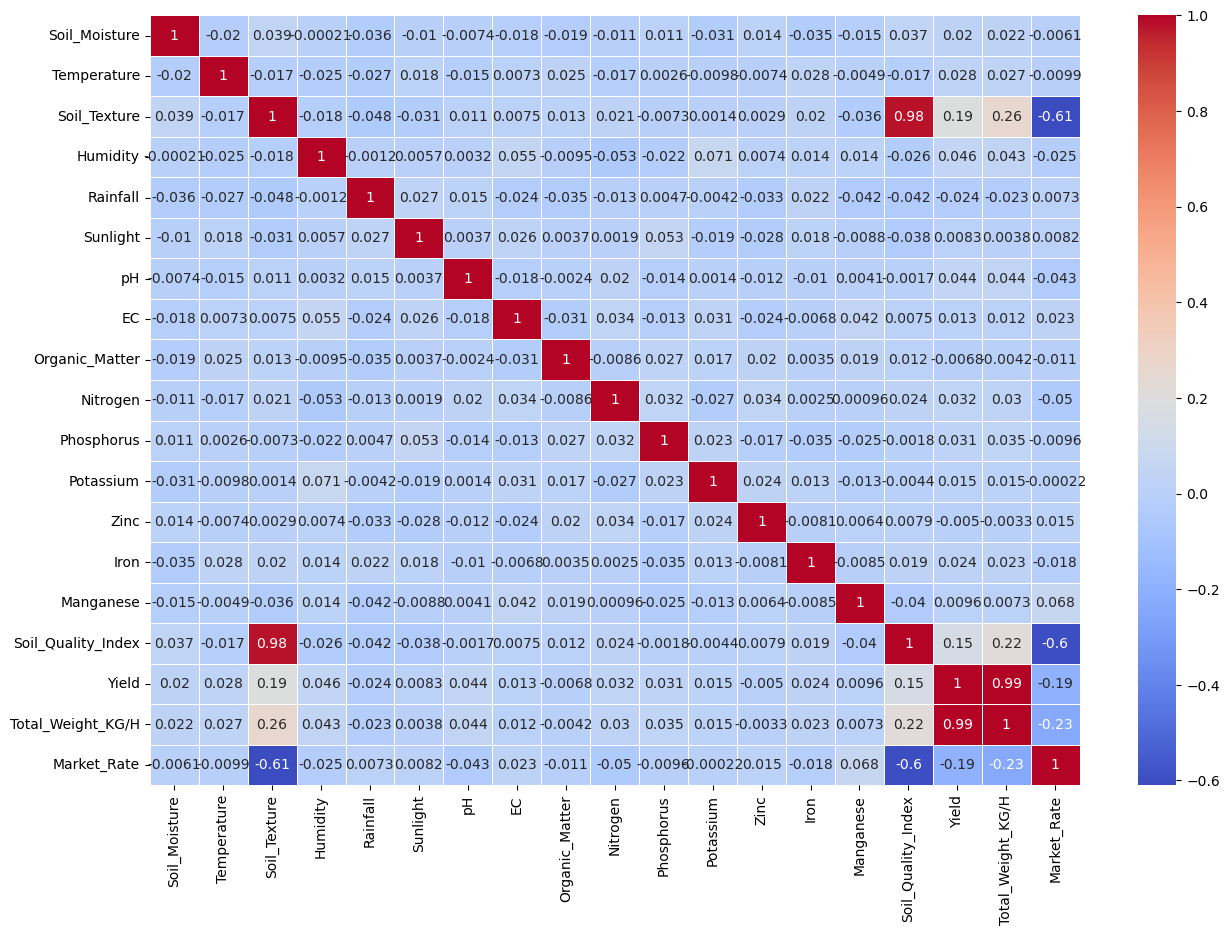

In [31]:
# Heatmap for correlation matrix
plt.figure(figsize=(15, 10))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.show()

In [32]:
# Define features (X) and target columns
X = df.drop(['Crop_Prediction', 'Yield', 'Soil_Quality'], axis=1)  # Features
y_crop = df['Crop_Prediction']  # Target for crop prediction
y_yield = df['Yield']  # Target for yield prediction
y_soil_quality = df['Soil_Quality']  # Target for soil quality prediction

In [33]:

# Create a new column 'NPK' by summing 'Nitrogen', 'Phosphorus', and 'Potassium'
df['NPK'] = df['Nitrogen'] + df['Phosphorus'] + df['Potassium']

# Drop the original Nitrogen, Phosphorus, and Potassium columns if desired
df = df.drop(columns=['Nitrogen', 'Phosphorus', 'Potassium'])

df


,Soil_Moisture,Temperature,Soil_Texture,Humidity,Rainfall,Sunlight,pH,EC,Organic_Matter,Zinc,Iron,Manganese,Soil_Quality_Index,Crop_Prediction,Yield,Soil_Quality,Total_Weight_KG/H,Market_Rate,NPK
0,29.7,35.2,4,58.0,10.0,6.5,6.5,1.1,8.6,4.6,93.1,21.0,9.8,Maize,72033.333333,Excellent,10805,0.15,180.7
1,31.8,29.4,4,58.8,6.0,8.7,5.0,2.9,0.5,3.2,57.2,26.4,9.0,Potato,19620.000000,Excellent,4905,0.25,215.0
2,29.6,21.5,2,35.8,228.9,6.1,6.3,0.8,0.9,8.5,26.7,46.8,5.0,Flax,1942.857143,Fair,1360,0.70,229.6
3,29.6,12.0,2,33.3,281.1,9.0,6.8,1.5,8.5,2.9,30.6,17.4,6.7,Sorghum,25555.555556,Fair,4600,0.18,231.0
4,11.4,20.1,2,37.8,207.0,5.0,7.4,1.0,9.5,6.7,33.8,44.1,5.7,Groundnut,2777.777778,Fair,2500,0.90,216.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1420,22.1,23.1,1,26.9,274.2,4.1,5.8,2.5,8.4,6.3,16.0,38.5,3.1,Mustard,3148.333333,Poor,1889,0.60,223.7
1421,11.1,24.3,0,50.8,44.2,10.9,6.9,0.1,3.5,3.1,81.0,40.6,1.6,Pearl Millet,5213.333333,Very Poor,1564,0.30,264.9
1422,25.7,17.3,1,32.3,127.0,7.8,6.7,1.0,3.0,8.3,37.8,29.0,3.3,Mustard,3148.333333,Poor,1889,0.60,203.9
1423,27.2,34.5,0,40.0,141.1,11.0,5.0,2.4,3.0,9.8,25.4,35.1,2.2,Quinoa,392.857143,Very Poor,1375,3.50,185.5


#### 4. Model Selection and Evaluation

In [34]:
from sklearn.preprocessing import StandardScaler

In [212]:
# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


#### 1. Soil Quality

In [302]:
X_Soil_Quality = df.loc[:, ['Soil_Quality_Index', 'Temperature', 'Soil_Moisture', 'Soil_Texture','NPK']]
X_Soil_Quality

,Soil_Quality_Index,Temperature,Soil_Moisture,Soil_Texture,NPK
0,9.8,35.2,29.7,4,180.7
1,9.0,29.4,31.8,4,215.0
2,5.0,21.5,29.6,2,229.6
3,6.7,12.0,29.6,2,231.0
4,5.7,20.1,11.4,2,216.3
...,...,...,...,...,...
1420,3.1,23.1,22.1,1,223.7
1421,1.6,24.3,11.1,0,264.9
1422,3.3,17.3,25.7,1,203.9
1423,2.2,34.5,27.2,0,185.5


In [303]:
X_Soil_Quality
y_soil_quality = df['Soil_Quality']

In [304]:
# Train-test split for each target
# Soil Quality

X_train, X_test, y_soil_quality_train, y_soil_quality_test = train_test_split(X_Soil_Quality, y_soil_quality, test_size=0.2, random_state=42)


In [305]:
# Train the Logistic Regression model
log_reg_model = LogisticRegression(random_state=42)
log_reg_model.fit(X_Soil_Quality, y_soil_quality)


LogisticRegression(random_state=42)

In [306]:
# Define the evaluation function
def evaluation(string, model, ind_var, y_act):
    print(string.center(50, '*'))
    pred = model.predict(ind_var)
    
    accuracy = accuracy_score(y_act, pred)
    print('Accuracy:', accuracy)
    
    precision = precision_score(y_act, pred, average='macro')
    print('Precision:', precision)
    
    recall = recall_score(y_act, pred, average='macro')
    print('Recall:', recall)
    
    f1 = f1_score(y_act, pred, average='macro')
    print('F1 Score:', f1)
    
    cm = confusion_matrix(y_act, pred)
    print('Confusion Matrix:\n', cm)

print("Logistic Regression Model\n")    
evaluation('Test Data Evaluation', log_reg_model, X_test, y_soil_quality_test)
print()

evaluation('Train Data Evaluation', log_reg_model, X_train, y_soil_quality_train)


Logistic Regression Model

***************Test Data Evaluation***************
Accuracy: 0.7789473684210526
Precision: 0.7728290521803782
Recall: 0.7685196061183094
F1 Score: 0.7698037837504416
Confusion Matrix:
 [[44  0 14  0  0]
 [ 0 34 11  4  0]
 [12  7 32  0  0]
 [ 0 11  0 51  1]
 [ 0  0  0  3 61]]

**************Train Data Evaluation***************
Accuracy: 0.8157894736842105
Precision: 0.8097439230428842
Recall: 0.8115286876255183
F1 Score: 0.8100329368556214
Confusion Matrix:
 [[172   0  31   0   0]
 [  0 176  44  17   0]
 [ 53  27 135   0   0]
 [  0  23   0 203   9]
 [  0   0   0   6 244]]


In [307]:
X_Soil_Quality.head(1).T

,0
Soil_Quality_Index,9.8
Temperature,35.2
Soil_Moisture,29.7
Soil_Texture,4.0
NPK,180.7


In [308]:
X_Soil_Quality.head(1).values

array([[  9.8,  35.2,  29.7,   4. , 180.7]])

In [309]:
Soil_Texture = 4
Soil_Moisture = 29.7
Temperature = 35.2
NPK = 180.7
Soil_Quality_Index = 9.8


In [312]:
test_soil_quality_array = np.zeros(X_Soil_Quality.shape[1])

In [331]:
# Assign the feature values to the array
test_soil_quality_array[0] = Soil_Quality_Index
test_soil_quality_array[1] = Temperature
test_soil_quality_array[2] = Soil_Moisture
test_soil_quality_array[3] = Soil_Texture
test_soil_quality_array[4] = NPK

In [332]:
# Print Project Data (feature names)
column_names = X_Soil_Quality.columns  # Extracting feature column names
project_soil_quality_data = {'columns': list(column_names)}
project_soil_quality_data

{'columns': ['Soil_Quality_Index',
  'Temperature',
  'Soil_Moisture',
  'Soil_Texture',
  'NPK']}

In [333]:
# Predict using the trained model
result = log_reg_model.predict([test_soil_quality_array])[0]  # Predict for a single row of input data
print(f'Soil Quality Prediction: {result}')

Soil Quality Prediction: 0


In [317]:
import pickle
import json

In [334]:
# Save the trained Logistic Regression model using pickle
with open('Soil_Quality_Model.pkl', 'wb') as f:
    pickle.dump(log_reg_model, f)

In [335]:
# Save project data (feature columns) into a JSON file
with open('project_data_soil_quality.json', 'w') as f:
    json.dump(project_data, f)


In [227]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Select the features for training
select_X_quality = df.loc[:, ['Soil_Quality_Index', 'Temperature', 'Soil_Moisture', 'Soil_Texture', 'NPK']]
X = select_X_quality
y_soil_quality = df['Soil_Quality']

# Encode the target variable (Soil Quality)
label_encoder = LabelEncoder()
y_soil_quality_encoded = label_encoder.fit_transform(y_soil_quality)

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split for each target
X_train, X_test, y_soil_quality_train, y_soil_quality_test = train_test_split(X_scaled, y_soil_quality_encoded, test_size=0.2, random_state=42)

# Train the Logistic Regression model
log_reg_model = LogisticRegression(random_state=42)
log_reg_model.fit(X_train, y_soil_quality_train)

# Define the evaluation function
def evaluation(string, model, ind_var, y_act):
    print(string.center(50, '*'))
    pred = model.predict(ind_var)
    
    # Inverse transform the predictions to get the original labels
    pred_labels = label_encoder.inverse_transform(pred)
    
    accuracy = accuracy_score(y_act, pred)
    print('Accuracy:', accuracy)
    
    precision = precision_score(y_act, pred, average='macro')
    print('Precision:', precision)
    
    recall = recall_score(y_act, pred, average='macro')
    print('Recall:', recall)
    
    f1 = f1_score(y_act, pred, average='macro')
    print('F1 Score:', f1)
    
    cm = confusion_matrix(y_act, pred)
    print('Confusion Matrix:\n', cm)
    
    print('Predicted Soil Quality:', pred_labels)

print("Logistic Regression Model\n")    
evaluation('Test Data Evaluation', log_reg_model, X_test, y_soil_quality_test)
print()

evaluation('Train Data Evaluation', log_reg_model, X_train, y_soil_quality_train)


Logistic Regression Model

***************Test Data Evaluation***************
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
Confusion Matrix:
 [[58  0  0  0  0]
 [ 0 49  0  0  0]
 [ 0  0 51  0  0]
 [ 0  0  0 63  0]
 [ 0  0  0  0 64]]
Predicted Soil Quality: [1 1 1 3 4 1 1 0 1 2 3 0 3 0 0 2 0 0 4 1 2 3 4 1 2 0 3 1 0 1 2 0 1 4 2 0 0
 1 4 3 3 3 3 3 4 2 3 4 2 0 1 4 4 2 3 4 1 3 3 4 4 3 2 1 0 0 0 4 2 0 0 3 3 3
 1 3 1 1 4 3 2 3 3 3 0 0 2 4 4 1 0 4 1 0 2 0 0 2 0 2 3 0 4 3 2 4 2 1 4 2 1
 4 0 4 3 3 2 4 0 3 2 3 0 0 3 4 4 0 1 2 0 2 4 0 4 1 0 3 3 4 3 3 2 1 3 0 0 4
 4 2 2 2 4 4 3 0 3 3 1 0 0 1 3 4 2 1 1 4 2 1 2 2 4 4 3 1 3 4 4 2 1 4 1 2 4
 3 2 4 3 0 1 4 4 4 3 1 4 1 4 3 2 4 0 4 2 0 0 4 2 0 1 3 4 2 2 2 2 0 4 1 3 2
 4 4 0 1 3 3 0 3 4 1 2 4 0 2 0 3 1 0 4 2 1 0 1 1 4 0 2 2 3 4 0 2 3 3 1 0 0
 1 4 3 3 3 2 1 0 2 0 3 4 4 3 4 3 1 0 0 4 3 4 2 3 1 3]

**************Train Data Evaluation***************
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
Confusion Matrix:
 [[203   0   0   0   0]
 [  0

#### 2. Crop Prediction

In [41]:
# Define features (X) and target columns
X = df.drop(['Crop_Prediction', 'Yield', 'Soil_Quality'], axis=1)  # Features
y_crop = df['Crop_Prediction']  # Target for crop prediction
y_yield = df['Yield']  # Target for yield prediction


In [42]:
# Initialize the LabelEncoder
label_encoder = LabelEncoder()
df['Soil_Quality'] = label_encoder.fit_transform(df['Soil_Quality'])
soil_texture_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
#print("Soil_Texture encoding:", soil_texture_mapping)

In [150]:

# Manually select features for crop prediction
selected_features = ['Soil_Texture','EC','Zinc','Soil_Quality_Index','Soil_Quality']
X_crop_prediction = df[selected_features]


In [151]:
# crop prediction
# Train-test split for each target
X_train, X_test, y_crop_train, y_crop_test = train_test_split(X_crop_prediction, y_crop, test_size=0.2, random_state=42)

In [152]:
# Train the Logistic Regression model
log_reg_model = LogisticRegression(random_state=42)
log_reg_model.fit(X_crop_prediction, y_crop)


LogisticRegression(random_state=42)

In [154]:
# Define the evaluation function
def evaluation(string, model, ind_var, y_act):
    print(string.center(50, '*'))
    pred = model.predict(ind_var)
    
    accuracy = accuracy_score(y_act, pred)
    print('Accuracy:', accuracy)
    
    precision = precision_score(y_act, pred, average='macro')
    print('Precision:', precision)
    
    recall = recall_score(y_act, pred, average='macro')
    print('Recall:', recall)
    
    f1 = f1_score(y_act, pred, average='macro')
    print('F1 Score:', f1)
    
    cm = confusion_matrix(y_act, pred)
    print('Confusion Matrix:\n', cm)

print("Logistic Regression Model\n")   
print("Crop Prediction\n")
evaluation('Test Data Evaluation', log_reg_model, X_test, y_crop_test)
print()

evaluation('Train Data Evaluation', log_reg_model, X_train, y_crop_train)


Logistic Regression Model

Crop Prediction

***************Test Data Evaluation***************
Accuracy: 0.7894736842105263
Precision: 0.6605385031831583
Recall: 0.6862233354880414
F1 Score: 0.6584560936493797
Confusion Matrix:
 [[17  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  5  0  0  0  0  0  0  0  0  3  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  7  0  0  3  0  0  0  0  0  0  0  0  0  2  0  0  1  0  0]
 [ 0  0  0  3  0  0  0  0  0  0  4  0  0  0  0  0  0  3  0  0  0]
 [ 0  0  0  0  3  2  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  3  0  4 13  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 18  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  7  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0 15  0  0  0  0  0  0  0  0  0  0  1  0]
 [ 0  0  0  0  0  0  0  0  0 16  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  5  0  0  0  0  0  0 12  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  9  0  1  

### Testing on single row

In [336]:
X_crop_prediction.head(1).T

,0
Soil_Texture,4.0
EC,1.1
Zinc,4.6
Soil_Quality_Index,9.8
Soil_Quality,0.0


In [337]:
Soil_Texture = 4.0
EC	= 1.1
Zinc = 4.6
Soil_Quality_Index	= 9.8
Soil_Quality = 0.0

In [338]:
test_crop_array = np.zeros(X_crop_prediction.shape[1])

In [339]:
# Assign the feature values to the array
test_crop_array[0] = Soil_Texture
test_crop_array[1] = EC
test_crop_array[2] = Zinc
test_crop_array[3] = Soil_Quality_Index
test_crop_array[4] = Soil_Quality

In [340]:
# Print Project Data (feature names)
column_names = X_crop_prediction.columns  # Extracting feature column names
project_crop_data = {'columns': list(column_names)}
project_crop_data

{'columns': ['Soil_Texture',
  'EC',
  'Zinc',
  'Soil_Quality_Index',
  'Soil_Quality']}

In [341]:
# Predict using the trained model
result = log_reg_model.predict([test_crop_array])[0]  # Predict for a single row of input data
print(f'Crop Prediction: {result}')

Crop Prediction: 0


In [342]:
# Save the trained Logistic Regression model using pickle
with open('Soil_Crop_Model.pkl', 'wb') as f:
    pickle.dump(log_reg_model, f)


In [343]:
# Save project data (feature columns) into a JSON file
with open('project_data_soil_Crop.json', 'w') as f:
    json.dump(project_data, f)


In [ ]:
Logistic with grid search algorithm

In [117]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Load your dataset (assuming it's already loaded as df)
# Define features (X) and target column (y_crop)
X = df.drop(['Crop_Prediction', 'Yield', 'Soil_Quality'], axis=1)  # Features
y_crop = df['Crop_Prediction']  # Target for crop prediction

# Encode Soil_Quality
label_encoder = LabelEncoder()
df['Soil_Quality'] = label_encoder.fit_transform(df['Soil_Quality'])
soil_texture_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))

# Select features for crop prediction
selected_features = ['Soil_Moisture', 'Temperature', 'Soil_Texture', 'Humidity', 'Rainfall', 'Sunlight', 'pH', 'EC', 'Organic_Matter', 'Zinc', 'Iron', 'Manganese', 'Soil_Quality_Index']
X_crop_prediction = df[selected_features]

# Train-test split
X_train, X_test, y_crop_train, y_crop_test = train_test_split(X_crop_prediction, y_crop, test_size=0.2, random_state=42)

# Define the Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, max_iter=1000)

# Define the parameter grid for GridSearchCV
param_grid = {
    'penalty': ['l1', 'l2', 'elasticnet', None],
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear', 'saga'],
    'class_weight': [None, 'balanced']
}

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=log_reg_model, param_grid=param_grid, scoring='accuracy', cv=5, verbose=1, n_jobs=-1)

# Fit the model
grid_search.fit(X_train, y_crop_train)

# Best parameters and model
best_params = grid_search.best_params_
print("Best Parameters:", best_params)

best_model = grid_search.best_estimator_

# Define the evaluation function
def evaluation(string, model, ind_var, y_act):
    print(string.center(50, '*'))
    pred = model.predict(ind_var)

    accuracy = accuracy_score(y_act, pred)
    print('Accuracy:', accuracy)

    precision = precision_score(y_act, pred, average='macro')
    print('Precision:', precision)

    recall = recall_score(y_act, pred, average='macro')
    print('Recall:', recall)

    f1 = f1_score(y_act, pred, average='macro')
    print('F1 Score:', f1)

    cm = confusion_matrix(y_act, pred)
    print('Confusion Matrix:\n', cm)

# Evaluate the model
print("Logistic Regression with GridSearchCV\n")
print("Crop Prediction\n")
evaluation('Test Data Evaluation', best_model, X_test, y_crop_test)
print()
evaluation('Train Data Evaluation', best_model, X_train, y_crop_train)


Fitting 5 folds for each of 120 candidates, totalling 600 fits
Best Parameters: {'C': 100, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'liblinear'}
Logistic Regression with GridSearchCV

Crop Prediction

***************Test Data Evaluation***************
Accuracy: 0.6421052631578947
Precision: 0.564854193425622
Recall: 0.5913364700129407
F1 Score: 0.5587931528020239
Confusion Matrix:
 [[17  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  3  0  0  0  0  0  0  0  0  4  0  0  0  0  0  0  0  1  0  0]
 [ 0  0  4  2  0  1  3  0  0  0  1  0  0  0  0  0  0  0  0  2  0]
 [ 0  0  2  3  0  1  0  0  0  0  1  0  0  0  0  0  0  2  1  0  0]
 [ 0  0  0  0  4  0  0  0  0  1  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  4  3  4  5  2  0  0  0  0  0  0  0  0  0  0  0  0  2  0]
 [ 0  0  2  0  0  3  8  0  0  0  0  0  0  0  0  0  0  0  0  5  0]
 [ 0  0  0  0  0  0  0  7  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0 10  0  0  0  0  0  0  3  0  0  2  1  0]
 [ 0  0

#### 3. Yeild Prediction

In [271]:
# Define features (X) and target columns
X = df.drop(['Crop_Prediction', 'Yield', 'Soil_Quality'], axis=1)  # Features
y_crop = df['Crop_Prediction']  # Target for crop prediction
y_yield = df['Yield']  # Target for yield prediction


In [272]:

# Manually select features for crop prediction
selected_features = ['Market_Rate','Total_Weight_KG/H','Soil_Texture','Rainfall']
X_yeild_prediction = df[selected_features]


In [273]:
# crop prediction
# Train-test split for each target
X_train, X_test, y_yeild_train, y_yeild_test = train_test_split(X_yeild_prediction, y_yield, test_size=0.2, random_state=42)

In [274]:
from sklearn.linear_model import LinearRegression

# Train the Linear Regression model
linear_reg = LinearRegression()
linear_reg.fit(X_yeild_prediction, y_yield)


LinearRegression()

In [169]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [275]:
def evaluation(string, model, ind_var, y_act):
    print(string.center(50, '*'))
    pred = model.predict(ind_var)
    
    mse = mean_squared_error(y_act, pred)
    print('MSE:', mse)
    
    rmse = np.sqrt(mse)
    print('RMSE:', rmse)
    
    mae = mean_absolute_error(y_act, pred)
    print('MAE :', mae)
    
    r_squared = r2_score(y_act, pred)
    print('R2_Score :', r_squared)
    
    adj_r2 = 1 - (((1-r_squared)*(ind_var.shape[0] - 1))/(ind_var.shape[0]- ind_var.shape[1]-1))
    print('Adj-R2_Score :', adj_r2)
print("Linear Regression Model\n")    
print("Yeild Prediction\n")
evaluation('Test Data Evaluation', linear_reg, X_test, y_yeild_test)
print()

evaluation('Train Data Evaluation', linear_reg, X_train, y_yeild_train)

Linear Regression Model

Yeild Prediction

***************Test Data Evaluation***************
MSE: 948684166.6278958
RMSE: 30800.716982367405
MAE : 20800.487062638487
R2_Score : 0.9935565837241913
Adj-R2_Score : 0.9934645349202512

**************Train Data Evaluation***************
MSE: 1149731336.0119047
RMSE: 33907.68844984725
MAE : 23852.49244949537
R2_Score : 0.9936845315027656
Adj-R2_Score : 0.993662274345066


## AdaBoostRegressor

In [276]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [277]:
# Define features (X) and target columns
X = df.drop(['Crop_Prediction', 'Yield', 'Soil_Quality'], axis=1)  # Features
y_yeild = df['Yield']  # Target for crop prediction


In [278]:
# Manually select features for crop prediction
selected_features = ['Market_Rate','Total_Weight_KG/H','Soil_Quality','Rainfall']
X_yeild_prediction = df[selected_features]

In [279]:
# Train-test split for each target
X_train, X_test, y_yeild_train, y_yeild_test = train_test_split(X_yeild_prediction, y_yeild, test_size=0.2, random_state=42)

In [280]:
# Train the AdaBoost Regressor model
adaboost_reg = AdaBoostRegressor(random_state=42, n_estimators=100)
adaboost_reg.fit(X_train, y_yeild_train)


AdaBoostRegressor(n_estimators=100, random_state=42)

In [281]:
# Evaluation function
def evaluation(string, model, ind_var, y_act):
    print(string.center(50, '*'))
    pred = model.predict(ind_var)

   
    
    mse = mean_squared_error(y_act, pred)
    print('MSE:', mse)
    
    rmse = np.sqrt(mse)
    print('RMSE:', rmse)
    
    mae = mean_absolute_error(y_act, pred)
    print('MAE:', mae)
    
    r_squared = r2_score(y_act, pred)
    print('R2_Score:', r_squared)
    
    adj_r2 = 1 - (((1 - r_squared) * (ind_var.shape[0] - 1)) / (ind_var.shape[0] - ind_var.shape[1] - 1))
    print('Adj-R2_Score:', adj_r2)


    

# Evaluate the model
print("AdaBoost Regressor Model\n")
print("Crop Prediction\n")
evaluation('Test Data Evaluation', adaboost_reg, X_test, y_yeild_test)
print()
evaluation('Train Data Evaluation', adaboost_reg, X_train, y_yeild_train)


AdaBoost Regressor Model

Crop Prediction

***************Test Data Evaluation***************
MSE: 3494507.055691944
RMSE: 1869.3600658225114
MAE: 1530.1804335350153
R2_Score: 0.9999762654796711
Adj-R2_Score: 0.999975926415095

**************Train Data Evaluation***************
MSE: 3749286.4878795543
RMSE: 1936.307436302292
MAE: 1559.1803591814391
R2_Score: 0.9999794051880125
Adj-R2_Score: 0.9999793326071773


### Testing on Single Row

In [282]:
X_yeild_prediction.head(1).T

,0
Market_Rate,0.15
Total_Weight_KG/H,10805.00
Soil_Quality,0.00
Rainfall,10.00


In [283]:
X_yeild_prediction.head(1).values

array([[1.5000e-01, 1.0805e+04, 0.0000e+00, 1.0000e+01]])

In [285]:
Market_Rate	= 0.15
Total_Weight_KG_H = 10805.00
Soil_Quality = 0.00
Rainfall = 10.00


In [291]:
# Create a feature array (same number of features as in the training model)
test_array_yield = np.zeros(X_yeild_prediction.shape[1])

In [292]:
# Assign the feature values to the array
test_array_yield[0] = Market_Rate
test_array_yield[1] = Total_Weight_KG_H
test_array_yield[2] = Soil_Quality
test_array_yield[3] = Rainfall


In [293]:
# Print Project Data (feature names for yield prediction)
column_names_yield = X_yeild_prediction.columns  # Extracting feature column names
project_data_yield = {'columns': list(column_names_yield)}
project_data_yield

{'columns': ['Market_Rate', 'Total_Weight_KG/H', 'Soil_Quality', 'Rainfall']}

In [294]:
# Predict using the trained AdaBoost Regressor model
yield_result = adaboost_reg.predict([test_array_yield])[0]  # Predict for a single row of input data
print(f'Yield Prediction: {round(yield_result, 2)}')

Yield Prediction: 72033.33


In [295]:
# Save the trained AdaBoost Regressor model using pickle
with open('Yield_Prediction_Model.pkl', 'wb') as f:
    pickle.dump(adaboost_reg, f)


In [296]:
# Save project data (feature columns) into a JSON file
with open('project_data_yield.json', 'w') as f:
    json.dump(project_data_yield, f)